In [ ]:
# loading data
import pandas as pd

file_name = "ASRS_DBOnline.csv"

df = pd.read_csv(file_name, header=[0, 1])

# Flatten header
df.columns = [' '.join(col).strip() for col in df.columns]

Narrative = "Report 1 Narrative"
Synopsis  = "Report 1 Synopsis"

df = df[[Narrative, Synopsis]]

df.head()

,Report 1 Narrative,Report 1 Synopsis
0,I was in the traffic pattern in a C172 with a ...,Flight instructor reported that while on the d...
1,After making a safe landing on runway; the stu...,Student pilot on training flight in a Mooney a...
2,I was approaching ZZZ at approximately XA:00 f...,C172 student pilot and instructor reported an ...
3,Aircraft X; was a SLC arrival from the south c...,Salt Lake City TRACON Controller reported a mi...
4,After taxiing to the ramp; I have instructed m...,CFI reported landing shortly after takeoff due...


In [ ]:
df = df[[Narrative, Synopsis]].copy()

# Convert to string
df[Narrative] = df[Narrative].astype(str)

# Count words in each narrative
df['word_count'] = df[Narrative].apply(lambda x: len(x.split()))

# Calculate statistics
mean_length = df['word_count'].mean()
std_length  = df['word_count'].std()
min_length  = df['word_count'].min()
max_length  = df['word_count'].max()

print("Total narratives:", len(df))
print("Mean narrative length:", round(mean_length, 2))
print("Standard deviation:", round(std_length, 2))
print("Minimum length:", min_length)
print("Maximum length:", max_length)


Total narratives: 1451
Mean narrative length: 250.58
Standard deviation: 196.39
Minimum length: 14
Maximum length: 2215


In [ ]:
# Convert synopsis column to string
df[Synopsis] = df[Synopsis].astype(str)

# Count words in each synopsis
df['synopsis_word_count'] = df[Synopsis].apply(lambda x: len(x.split()))

# Calculate statistics
syn_mean = df['synopsis_word_count'].mean()
syn_std  = df['synopsis_word_count'].std()
syn_min  = df['synopsis_word_count'].min()
syn_max  = df['synopsis_word_count'].max()

print("Total synopses:", len(df))
print("Mean synopsis length:", round(syn_mean, 2))
print("Standard deviation:", round(syn_std, 2))
print("Minimum synopsis length:", syn_min)
print("Maximum synopsis length:", syn_max)


Total synopses: 1451
Mean synopsis length: 23.97
Standard deviation: 10.66
Minimum synopsis length: 5
Maximum synopsis length: 86


In [ ]:
# cleaning data
def clean_text(text):
    return " ".join(str(text).split()).lower()

df["Narrative_clean"] = df[Narrative].apply(clean_text)
df["Synopsis_clean"]  = df[Synopsis].apply(clean_text)

In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np
model = SentenceTransformer('all-MiniLM-L6-v2')

narrative_texts = df["Narrative_clean"].tolist()

narratives_embeddings = model.encode(narrative_texts, batch_size=32, show_progress_bar=True)
narratives_embeddings = np.array(narratives_embeddings)
narratives_embeddings.shape

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/46 [00:00<?, ?it/s]

(1451, 384)

In [ ]:
np.save("narratives_embeddings.npy", narratives_embeddings)

Silhouette score for k=2: 0.0730


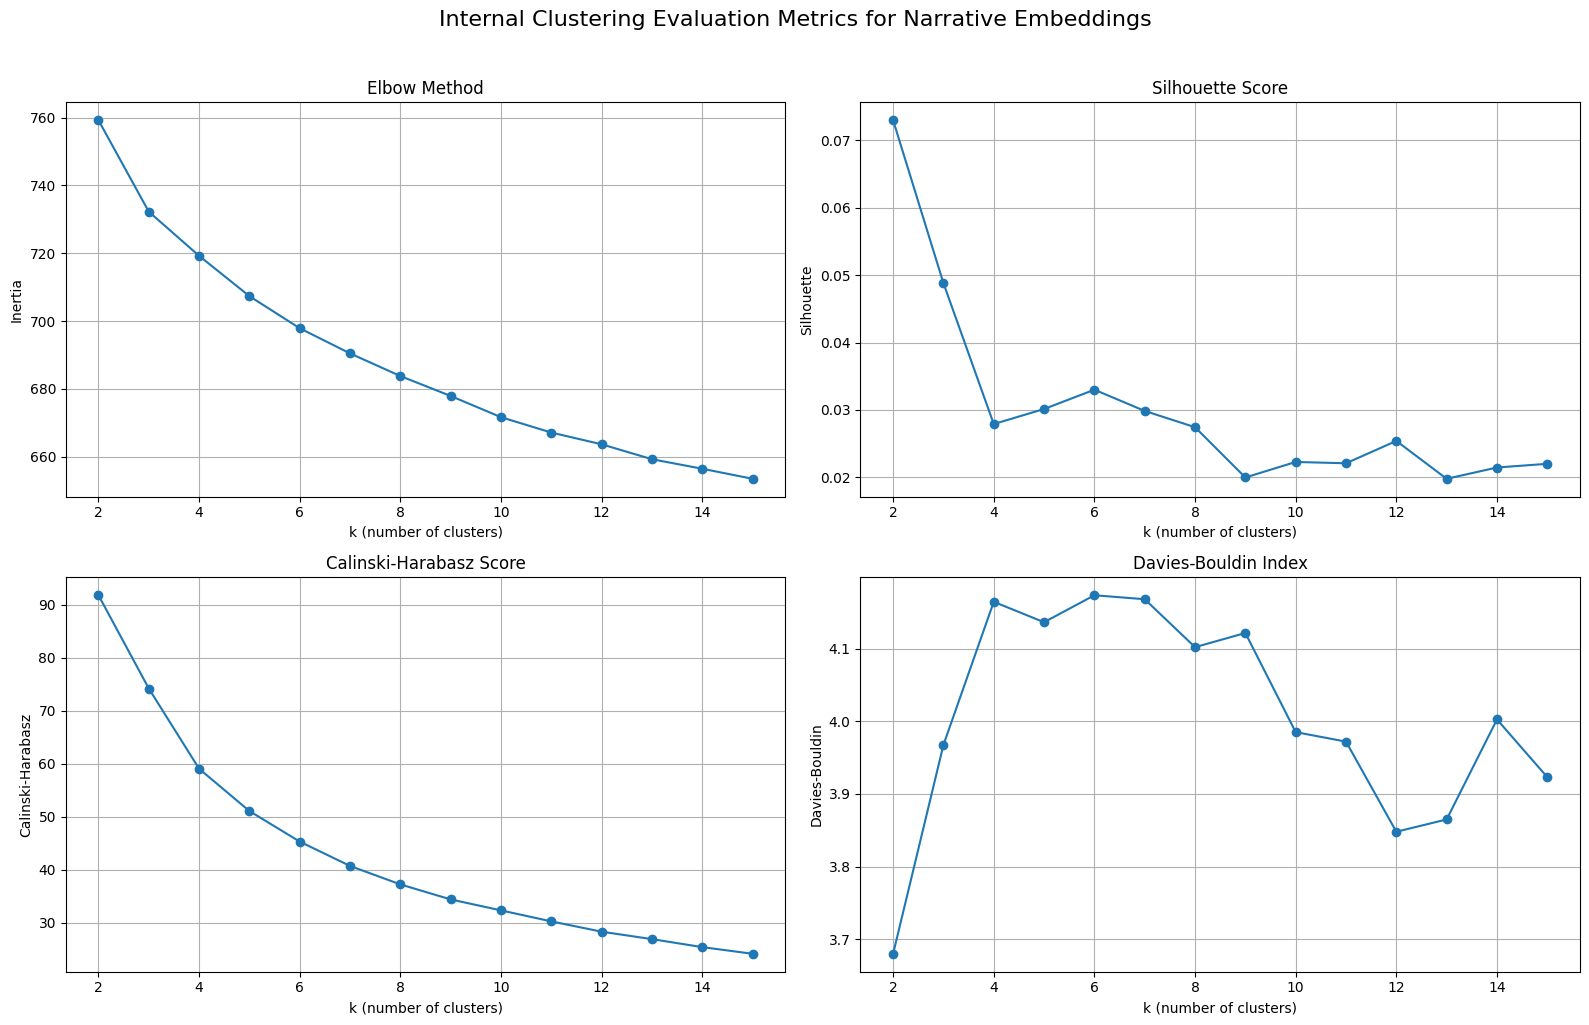

In [ ]:
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

# Range of k to test
k_values = range(2, 16)

inertias = []
sil_scores = []
ch_scores = []
db_scores = []

# Loop over k and compute metrics
for k in k_values:
    narratives_kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    narratives_labels = narratives_kmeans.fit_predict(narratives_embeddings)

    # Inertia
    inertias.append(narratives_kmeans.inertia_)

    # Silhouette score
    sil = silhouette_score(narratives_embeddings, narratives_labels)
    sil_scores.append(sil)

    # Calinski–Harabasz score
    ch = calinski_harabasz_score(narratives_embeddings, narratives_labels)
    ch_scores.append(ch)

    # Davies–Bouldin score
    db = davies_bouldin_score(narratives_embeddings, narratives_labels)
    db_scores.append(db)

# Find optimal k based on silhouette score
best_idx = np.argmax(sil_scores)          # index of max silhouette
best_k = list(k_values)[best_idx]         # corresponding k
best_sil = sil_scores[best_idx]           # best silhouette value

print(f"Silhouette score for k={best_k}: {best_sil:.4f}")


# Plot metrics
plt.figure(figsize=(16, 10))
plt.suptitle("Internal Clustering Evaluation Metrics for Narrative Embeddings", fontsize=16, y=1.02)

# Elbow
plt.subplot(2, 2, 1)
plt.plot(list(k_values), inertias, marker='o')
plt.title("Elbow Method")
plt.xlabel("k (number of clusters)")
plt.ylabel("Inertia")
plt.grid(True)

# Silhouette
plt.subplot(2, 2, 2)
plt.plot(list(k_values), sil_scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("k (number of clusters)")
plt.ylabel("Silhouette")
plt.grid(True)

# Calinski–Harabasz
plt.subplot(2, 2, 3)
plt.plot(list(k_values), ch_scores, marker='o')
plt.title("Calinski-Harabasz Score")
plt.xlabel("k (number of clusters)")
plt.ylabel("Calinski-Harabasz")
plt.grid(True)

# Davies–Bouldin
plt.subplot(2, 2, 4)
plt.plot(list(k_values), db_scores, marker='o')
plt.title("Davies-Bouldin Index")
plt.xlabel("k (number of clusters)")
plt.ylabel("Davies-Bouldin")
plt.grid(True)

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


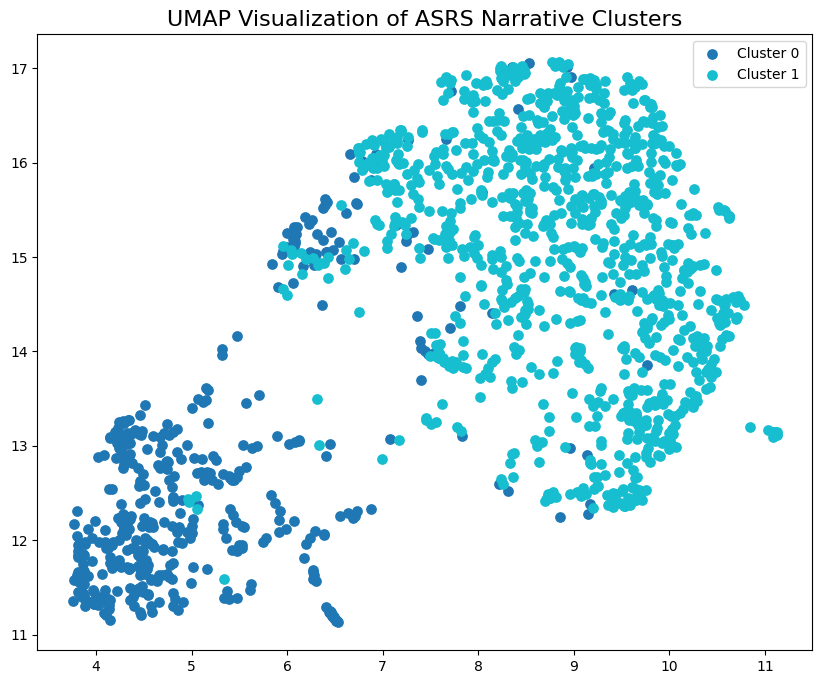

In [ ]:
import umap

k_narrative = 2

narrative_kmeans = KMeans(
    n_clusters=k_narrative,
    random_state=42,
    n_init=10      # how many times to run k-means with different seeds
)

narrative_labels = narrative_kmeans.fit_predict(narratives_embeddings)

# 2D UMAP for visualization
narratives_umap = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.0,
    metric='cosine',
    random_state=42
).fit_transform(narratives_embeddings)

narrative_unique_labels = np.unique(narrative_labels)

plt.figure(figsize=(10, 8))

narrative_colors = plt.cm.tab10(np.linspace(0, 1, len(narrative_unique_labels)))

for lab, color in zip(narrative_unique_labels, narrative_colors):
    narrative_mask = (narrative_labels == lab)
    plt.scatter(
        narratives_umap[narrative_mask, 0],
        narratives_umap[narrative_mask, 1],
        s=45,
        color=color,
        label=f'Cluster {lab}'
    )

plt.title("UMAP Visualization of ASRS Narrative Clusters", fontsize=16)
plt.legend()
plt.show()

In [ ]:
synopsis_texts = df["Synopsis_clean"].tolist()

synopsis_embeddings = model.encode(synopsis_texts, batch_size=32, show_progress_bar=True)
synopsis_embeddings = np.array(synopsis_embeddings)
synopsis_embeddings.shape

Batches:   0%|          | 0/46 [00:00<?, ?it/s]

(1451, 384)

In [ ]:
np.save("synopsis_embeddings.npy", synopsis_embeddings)

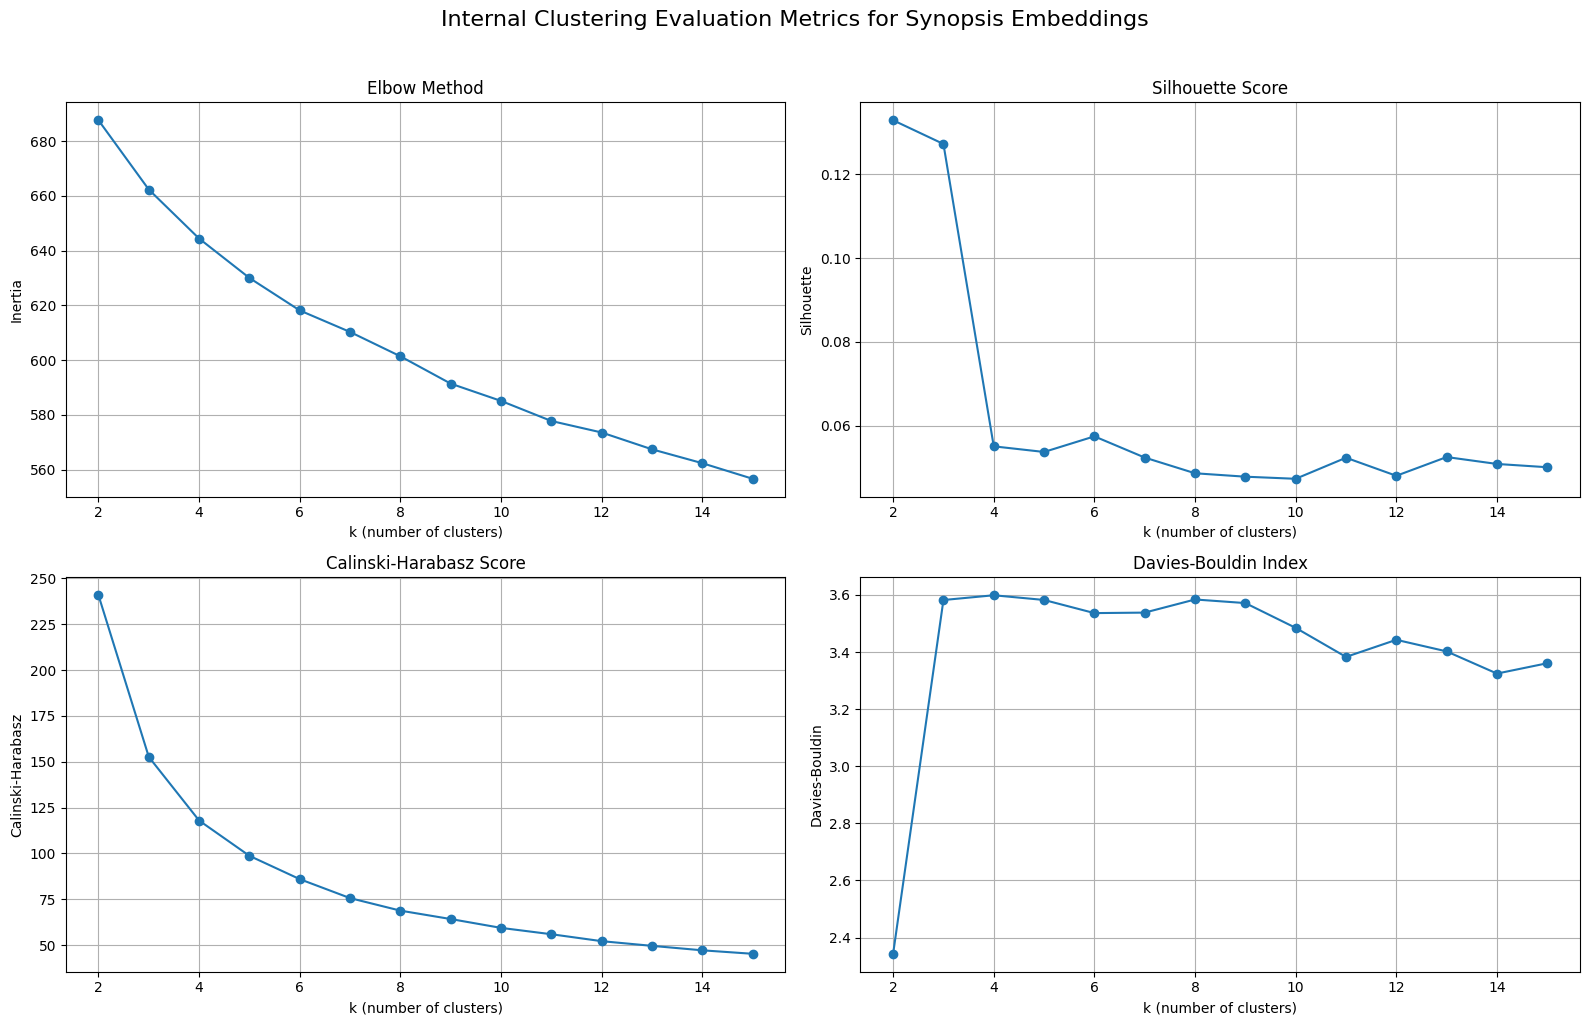

In [ ]:
# Range of k to test
k_values = range(2, 16)

inertias = []
sil_scores = []
ch_scores = []
db_scores = []

# Loop over k and compute metrics
for k in k_values:
    synopsis_kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    synopsis_labels = synopsis_kmeans.fit_predict(synopsis_embeddings)

    # Inertia
    inertias.append(synopsis_kmeans.inertia_)

    # Silhouette score
    sil = silhouette_score(synopsis_embeddings,  synopsis_labels)
    sil_scores.append(sil)

    # Calinski–Harabasz score
    ch = calinski_harabasz_score(synopsis_embeddings,  synopsis_labels)
    ch_scores.append(ch)

    # Davies–Bouldin score
    db = davies_bouldin_score(synopsis_embeddings,  synopsis_labels)
    db_scores.append(db)

# Plot metrics
plt.figure(figsize=(16, 10))
plt.suptitle("Internal Clustering Evaluation Metrics for Synopsis Embeddings", fontsize=16, y=1.02)

# Elbow
plt.subplot(2, 2, 1)
plt.plot(list(k_values), inertias, marker='o')
plt.title("Elbow Method")
plt.xlabel("k (number of clusters)")
plt.ylabel("Inertia")
plt.grid(True)

# Silhouette
plt.subplot(2, 2, 2)
plt.plot(list(k_values), sil_scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("k (number of clusters)")
plt.ylabel("Silhouette")
plt.grid(True)

# Calinski–Harabasz
plt.subplot(2, 2, 3)
plt.plot(list(k_values), ch_scores, marker='o')
plt.title("Calinski-Harabasz Score")
plt.xlabel("k (number of clusters)")
plt.ylabel("Calinski-Harabasz")
plt.grid(True)

# Davies–Bouldin
plt.subplot(2, 2, 4)
plt.plot(list(k_values), db_scores, marker='o')
plt.title("Davies-Bouldin Index")
plt.xlabel("k (number of clusters)")
plt.ylabel("Davies-Bouldin")
plt.grid(True)

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


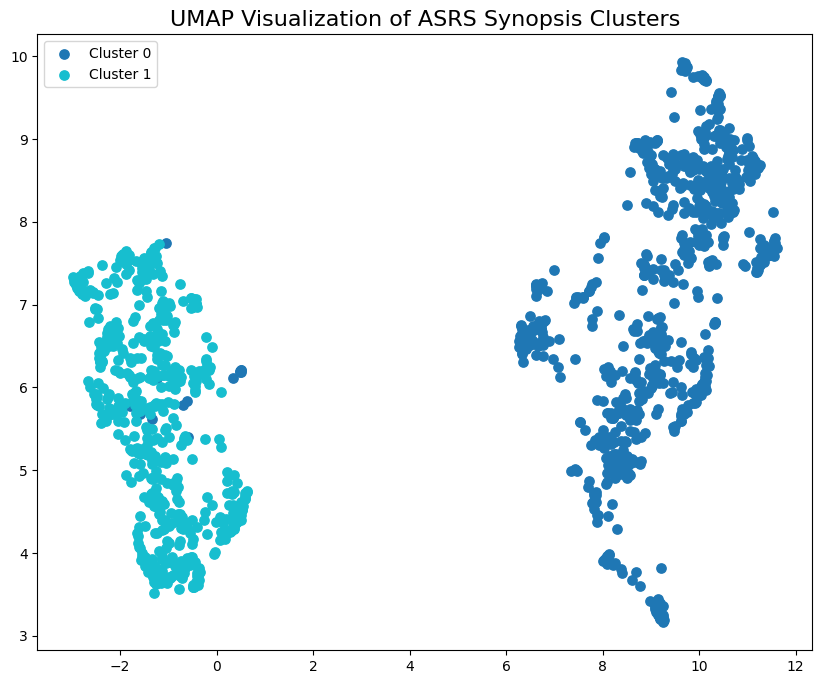

In [ ]:
k_synopsis = 2

synopsis_kmeans = KMeans(
    n_clusters=k_synopsis,
    random_state=42,
    n_init=10      # how many times to run k-means with different seeds
)

synopsis_labels = synopsis_kmeans.fit_predict(synopsis_embeddings)

# 2D UMAP for visualization
synopsis_umap = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.0,
    metric='cosine',
    random_state=42
).fit_transform(synopsis_embeddings)

synopsis_unique_labels = np.unique(synopsis_labels)

plt.figure(figsize=(10, 8))

synopsis_colors = plt.cm.tab10(np.linspace(0, 1, len(synopsis_unique_labels)))

for lab, color in zip(synopsis_unique_labels, synopsis_colors):
    synopsis_mask = (synopsis_labels == lab)
    plt.scatter(
        synopsis_umap[synopsis_mask, 0],
        synopsis_umap[synopsis_mask, 1],
        s=45,
        color=color,
        label=f'Cluster {lab}'
    )

plt.title("UMAP Visualization of ASRS Synopsis Clusters", fontsize=16)
plt.legend()
plt.show()

In [ ]:
df_eval = pd.DataFrame({
    "NarrativeCluster": narrative_labels,
    "SynopsisCluster": synopsis_labels
})
df["NarrativeCluster"] = narrative_labels
df["SynopsisCluster"] = synopsis_labels

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from scipy.optimize import linear_sum_assignment

# Get true and predicted labels
y_true = df["SynopsisCluster"].values        # expert labels
y_pred = df["NarrativeCluster"].values       # narrative clusters

# Build confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Hungarian algorithm to find best mapping
row_ind, col_ind = linear_sum_assignment(-cm)

mapping = {pred: true for true, pred in zip(row_ind, col_ind)}

# Apply mapping to narrative clusters
df["NarrativeMapped"] = df["NarrativeCluster"].map(mapping)
y_mapped = df["NarrativeMapped"].values

# Evaluation Metrics
acc  = accuracy_score(y_true, y_mapped)
prec = precision_score(y_true, y_mapped, average="macro")
rec  = recall_score(y_true, y_mapped, average="macro")
f1   = f1_score(y_true, y_mapped, average="macro")

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1:        {f1:.4f}")


Accuracy:  0.7092
Precision: 0.7805
Recall:    0.7470
F1:        0.7058


<Figure size 500x400 with 0 Axes>

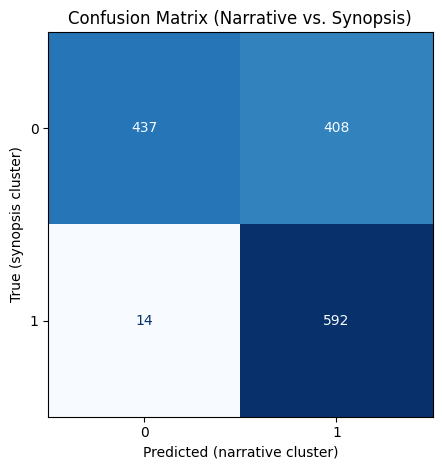

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

# Compute confusion matrix using mapped labels
cm_mapped = confusion_matrix(y_true, y_mapped)

# Plot confusion matrix
plt.figure(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_mapped,
                              display_labels=np.unique(y_true))
disp.plot(values_format="d", cmap="Blues", colorbar=False)
plt.title("Confusion Matrix (Narrative vs. Synopsis)")
plt.xlabel("Predicted (narrative cluster)")
plt.ylabel("True (synopsis cluster)")
plt.tight_layout()
plt.show()

In [ ]:
df["NarrativeCluster"].value_counts()

,count
NarrativeCluster,
1,1000
0,451


In [ ]:
df["SynopsisCluster"].value_counts()

In [ ]:
cluster0_samples = df[df["NarrativeCluster"] == 0][Narrative].head(5)

print("Cluster 0: Sample Narratives")
for i, text in enumerate(cluster0_samples, start=1):
    print(f"{i}. {text}\n")

Cluster 0: Sample Narratives
1. After making a safe landing on runway; the student accidentally released the 'Johnson Bar' gear handle causing the gear to retract on the landing roll. I immediately tried to force the handle back into its gear down and locked position; while the belly of the aircraft impacted the surface of the runway and the aircraft began to depart the runway to the right. I immediately pulled the mixture into the idle cutoff; and steered the aircraft using the rudder controls to avoid runway lights. The aircraft came to a rest on the right side of the runway in the grass. I turned off the master; fuel valve; and took the key out of the ignition. We both left the aircraft immediately with no injuries to either of us at all.

2. After taxiing to the ramp; I have instructed my student to switch tank from L to R as it is in his side (and asked my student if he did it according to the procedures of feeling the click while doing so and I checked the Fuel flow gauge which w

In [ ]:
cluster1_samples = df[df["NarrativeCluster"] == 1][Narrative].head(5)

print("Cluster 1: Sample Narratives")
for i, text in enumerate(cluster1_samples, start=1):
    print(f"{i}. {text}\n")

Cluster 1: Sample Narratives
1. I was in the traffic pattern in a C172 with a student pilot; teaching pattern work. I announced 45 degree entry to right downwind Runway XX at ZZZ. When we reached the downwind leg; I announced downwind leg. I was startled to hear from Aircraft Y that he too was downwind Runway XX. I immediately asked him to state your position. He said he was over the freeway. The freeway is about 3 miles from the runway. I told him that the freeway was not in the pattern.Moments later; once abeam the numbers to Runway XX; I was startled to see Aircraft Y go directly underneath us toward the runway; then make a 360 and join the pattern below us.I asked him: 'Aircraft Y; what are you doing?' He said; 'I saw you in the pattern so I decided to go below you.' This is highly unsafe practice. He nearly collided with us. Later; he landed on Runway XX while we were still on the runway in our landing roll. Someone should reach out to this pilot and provide remedial training. A F

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Filter by cluster
texts_cluster0 = df[df["NarrativeCluster"] == 0][Narrative]
texts_cluster1 = df[df["NarrativeCluster"] == 1][Narrative]

# Vectorize cluster 0
vectorizer0 = CountVectorizer(stop_words="english")
X0 = vectorizer0.fit_transform(texts_cluster0)
freq0 = pd.DataFrame(
    X0.toarray(),
    columns=vectorizer0.get_feature_names_out()
).sum().sort_values(ascending=False)

# Vectorize cluster 1
vectorizer1 = CountVectorizer(stop_words="english")
X1 = vectorizer1.fit_transform(texts_cluster1)
freq1 = pd.DataFrame(
    X1.toarray(),
    columns=vectorizer1.get_feature_names_out()
).sum().sort_values(ascending=False)

print("Top words in cluster 0:")
print(freq0.head(20))
print("\nTop words in cluster 1:")
print(freq1.head(20))


Top words in cluster 0:
runway        1450
aircraft      1078
student        971
landing        644
flight         559
left           537
right          449
plane          414
pilot          390
zzz            323
did            310
power          303
instructor     297
engine         290
taxiway        289
control        274
xx             271
ground         253
airplane       241
taxi           234
dtype: int64

Top words in cluster 1:
aircraft    4758
runway      2442
traffic     2392
pattern     1420
student     1369
downwind    1185
left        1161
right       1156
flight      1136
approach    1071
turn         968
final        945
zzz          940
pilot        892
tower        871
xx           832
did          832
radio        802
altitude     763
time         669
dtype: int64


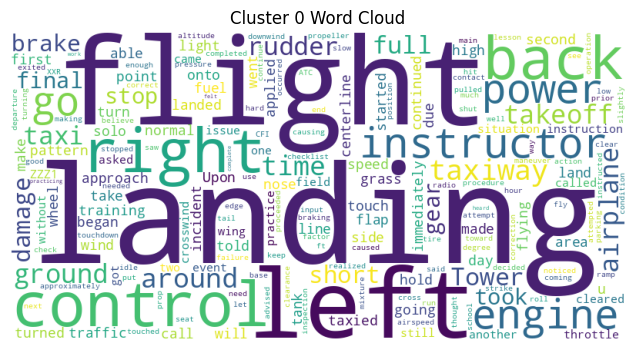

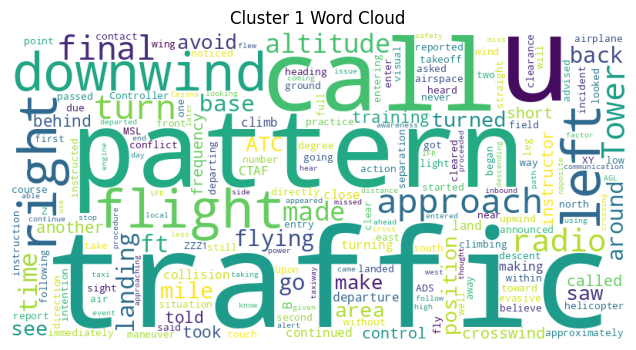

In [ ]:
from wordcloud import WordCloud, STOPWORDS

np.random.seed(42)

# base stopwords
stopwords = set(STOPWORDS)

# adding domain-specific common words that appear in both clusters
stopwords.update([
    "aircraft", "runway", "student", "pilot", "plane",
    "zzz", "xx", "rwy", "airport", "feet", "did", "x", "y"
])

text0 = " ".join(texts_cluster0)
text1 = " ".join(texts_cluster1)

wc0 = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords=stopwords,
    collocations=False,
    random_state=42
).generate(text0)

wc1 = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords=stopwords,
    collocations=False,
    random_state=42
).generate(text1)

# Plot Cluster 0
plt.figure(figsize=(10, 4))
plt.imshow(wc0)
plt.title("Cluster 0 Word Cloud")
plt.axis("off")
plt.show()

# Plot Cluster 1
plt.figure(figsize=(10, 4))
plt.imshow(wc1)
plt.title("Cluster 1 Word Cloud")
plt.axis("off")
plt.show()

## Model Comparisons


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

Narrative = "Report 1 Narrative"

# Make sure narratives are strings
df[Narrative] = df[Narrative].astype(str)

# TF-IDF representation
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=5,
    stop_words='english'
)

X_tfidf = tfidf.fit_transform(df[Narrative])
print("TF-IDF shape:", X_tfidf.shape)

# KMeans clustering on TF-IDF
k_tfidf = 2
tfidf_kmeans = KMeans(n_clusters=k_tfidf, random_state=42, n_init=10)
tfidf_labels = tfidf_kmeans.fit_predict(X_tfidf)

# Silhouette score (optional, for comparison)
sil_tfidf = silhouette_score(X_tfidf, tfidf_labels)
print("TF-IDF silhouette score (k=2):", sil_tfidf)

# 👉 Cluster sizes
unique, counts = np.unique(tfidf_labels, return_counts=True)
for lab, cnt in zip(unique, counts):
    print(f"TF-IDF Cluster {lab}: {cnt} reports")


TF-IDF shape: (1451, 5000)
TF-IDF silhouette score (k=2): 0.013698454803478645
TF-IDF Cluster 0: 473 reports
TF-IDF Cluster 1: 978 reports


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


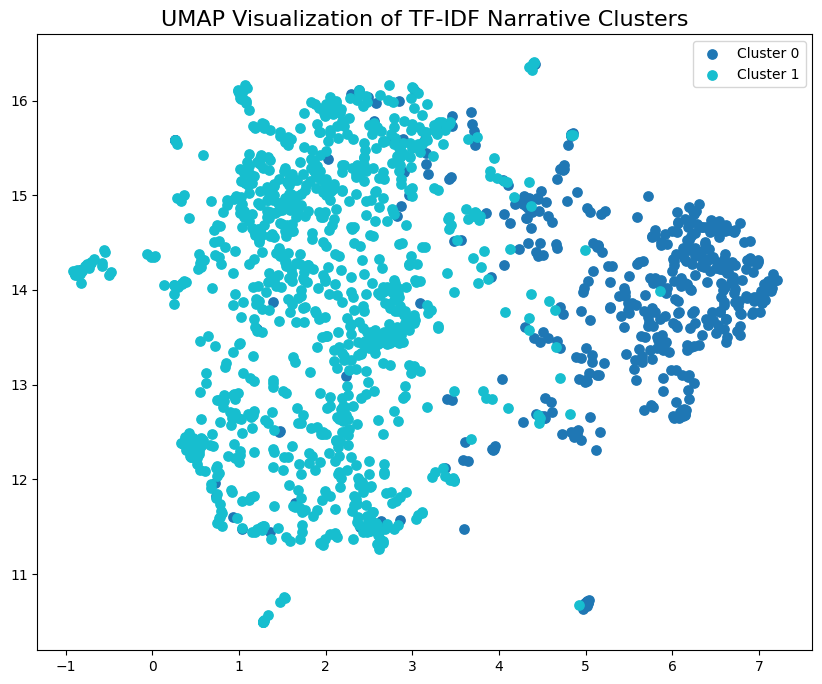

In [ ]:
import umap
import matplotlib.pyplot as plt
import numpy as np

# 2D UMAP for TF-IDF
tfidf_umap = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.0,
    metric='cosine',
    random_state=42
).fit_transform(X_tfidf)

tfidf_unique_labels = np.unique(tfidf_labels)

plt.figure(figsize=(10, 8))

# same colormap style as SBERT
colors = plt.cm.tab10(np.linspace(0, 1, len(tfidf_unique_labels)))

for lab, color in zip(tfidf_unique_labels, colors):
    mask = (tfidf_labels == lab)
    plt.scatter(
        tfidf_umap[mask, 0],
        tfidf_umap[mask, 1],
        s=45,
        color=color,
        label=f'Cluster {lab}'
    )

plt.title("UMAP Visualization of TF-IDF Narrative Clusters", fontsize=16)
plt.legend()
plt.show()


Batches:   0%|          | 0/46 [00:00<?, ?it/s]

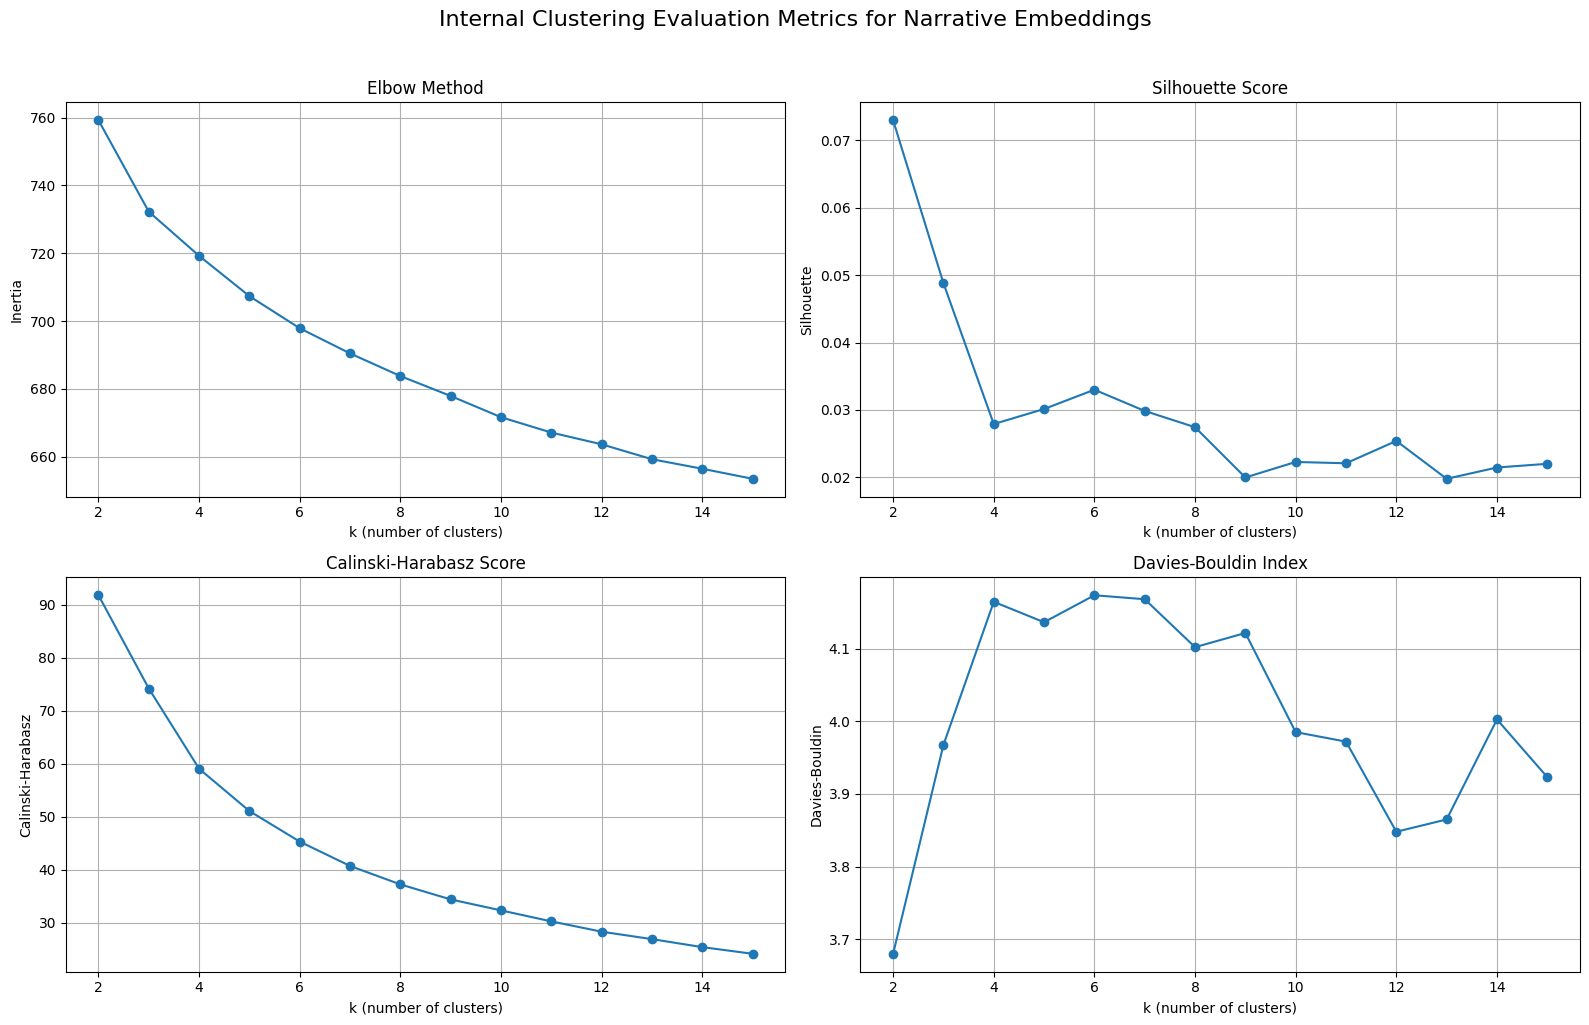

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


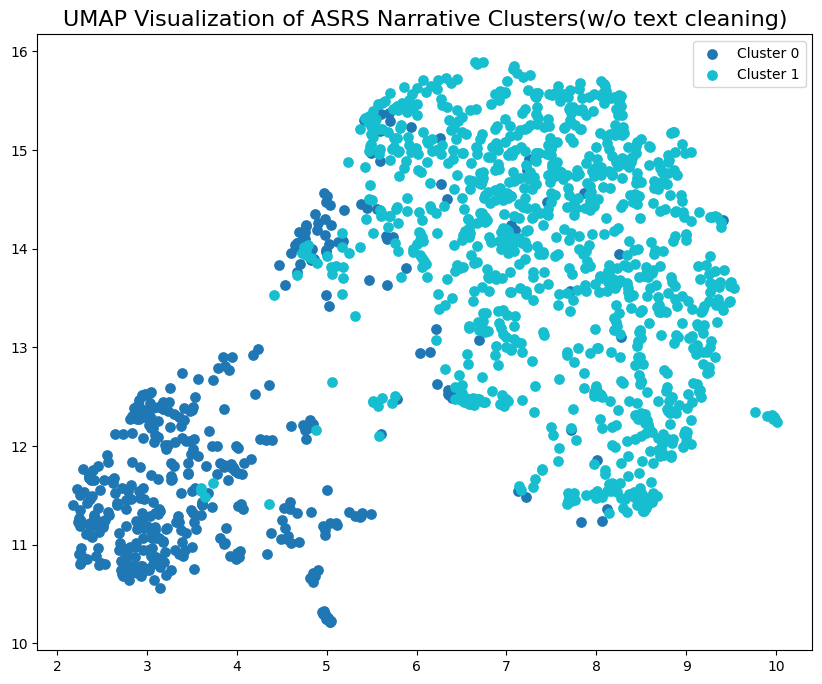

In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np
model = SentenceTransformer('all-MiniLM-L6-v2')

narrative_texts = df[Narrative].tolist()

narratives_embeddings = model.encode(narrative_texts, batch_size=32, show_progress_bar=True)
narratives_embeddings = np.array(narratives_embeddings)
narratives_embeddings.shape

import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

# Range of k to test
k_values = range(2, 16)

inertias = []
sil_scores = []
ch_scores = []
db_scores = []

# Loop over k and compute metrics
for k in k_values:
    narratives_kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    narratives_labels = narratives_kmeans.fit_predict(narratives_embeddings)

    # Inertia
    inertias.append(narratives_kmeans.inertia_)

    # Silhouette score
    sil = silhouette_score(narratives_embeddings, narratives_labels)
    sil_scores.append(sil)

    # Calinski–Harabasz score
    ch = calinski_harabasz_score(narratives_embeddings, narratives_labels)
    ch_scores.append(ch)

    # Davies–Bouldin score
    db = davies_bouldin_score(narratives_embeddings, narratives_labels)
    db_scores.append(db)

# Plot metrics
plt.figure(figsize=(16, 10))
plt.suptitle("Internal Clustering Evaluation Metrics for Narrative Embeddings", fontsize=16, y=1.02)

# Elbow
plt.subplot(2, 2, 1)
plt.plot(list(k_values), inertias, marker='o')
plt.title("Elbow Method")
plt.xlabel("k (number of clusters)")
plt.ylabel("Inertia")
plt.grid(True)

# Silhouette
plt.subplot(2, 2, 2)
plt.plot(list(k_values), sil_scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("k (number of clusters)")
plt.ylabel("Silhouette")
plt.grid(True)

# Calinski–Harabasz
plt.subplot(2, 2, 3)
plt.plot(list(k_values), ch_scores, marker='o')
plt.title("Calinski-Harabasz Score")
plt.xlabel("k (number of clusters)")
plt.ylabel("Calinski-Harabasz")
plt.grid(True)

# Davies–Bouldin
plt.subplot(2, 2, 4)
plt.plot(list(k_values), db_scores, marker='o')
plt.title("Davies-Bouldin Index")
plt.xlabel("k (number of clusters)")
plt.ylabel("Davies-Bouldin")
plt.grid(True)

plt.tight_layout()
plt.show()

import umap

k_narrative = 2

narrative_kmeans = KMeans(
    n_clusters=k_narrative,
    random_state=42,
    n_init=10      # how many times to run k-means with different seeds
)

narrative_labels = narrative_kmeans.fit_predict(narratives_embeddings)

# 2D UMAP for visualization
narratives_umap = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.0,
    metric='cosine',
    random_state=42
).fit_transform(narratives_embeddings)

narrative_unique_labels = np.unique(narrative_labels)

plt.figure(figsize=(10, 8))

narrative_colors = plt.cm.tab10(np.linspace(0, 1, len(narrative_unique_labels)))

for lab, color in zip(narrative_unique_labels, narrative_colors):
    narrative_mask = (narrative_labels == lab)
    plt.scatter(
        narratives_umap[narrative_mask, 0],
        narratives_umap[narrative_mask, 1],
        s=45,
        color=color,
        label=f'Cluster {lab}'
    )

plt.title("UMAP Visualization of ASRS Narrative Clusters(w/o text cleaning)", fontsize=16)
plt.legend()
plt.show()